### Practical Classification: Logistic Regression and Support Vector Machines

Classification is an important task in data science: given some data Two common classification algorithms are logistic regression and support vector machines (SVMs), but there are _many_ algorithms to [choose from](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py). In this homework we'll walk through some practical examples of binary classification: where data can either be one of two classes, which we label 0 or 1. Ultimately, both logistic regression and SVM _try to find a line that seperates the input data on one of two sides_.

<center>Fig. 1: SVM (dashed) and Logistic Regression (solid) decision boundaries</center>
<center>![alt](figs/class_ex.png)</center>

Just like we saw in least squares regression, depending on our choice of loss function our results changed. One way to compare SVM and logistic regression is to compare their loss functions:

SVM loss: $\mathcal{L}(y, \hat{y}) = \sum_{i} y_i - \max(0, 1 - y_{i}\omega^{T}x_{i})$

Logistic Regression loss: $\mathcal{L}(y, \hat{y}) = \sum_{i} y_i - \log(1 + e^{1 - y_{i}\omega^{T}x_{i}})$

Notice the $\omega^{T}x$ term defines a line, just like we saw in regression. Minimizing these loss functions with respect to the weights $\omega$ achieve our target goal of mapping inputs $x_{i}$ to integer classes 0 or 1, drawing a line between the classes. 

Logistic Regression is more sensitive to outliers, but its loss function is differentiable and important in many applications. SVM is robust to outliers and easy to apply non-linear kernels to (when the data isn't separable by a straight line), but like linear regression with L1 regularization (LASSO), requires a slower algorithm to determine a loss-minimizing solution.

The logistic loss function is derived from the [logistic function](https://en.wikipedia.org/wiki/Logistic_function). What's important to notice is that the output switches between 0 and 1---gradually---based on the input value. This is a critical ingredient for neural networks which we'll get to make use of in future assignments and party why it's called a _neural_ network. Biological neurons switch from outputing [no signal to outputting a full signal once](https://en.wikipedia.org/wiki/All-or-none_law) they've recieved a sufficient signal from input neurons, with some noisy-ness due in part to the chemical process that governs the input and output interactions. The probability that a neuron will fire looks a lot like a logistic function.

<center>Fig. 2: Outputing 0 or 1</center>
<center>![alt](figs/logistic_func.png)</center>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

We seen in previous assignments how to use sklearn's built in data analysis tools. Using these classification algorithms is very similar, so I won't be providing example code. I've imported the appropriate libraries above. Read the manpages for [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) and [SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) before starting the assignment to see example usage and what each input value is for. Just like the previous assignments we declare a model object, then use the .fit() method.

You will also need to compute the precision and recall of your classifiers. Refer to this really good [Wikipedia article](https://en.wikipedia.org/wiki/Precision_and_recall) on the difference. Either write your own functions, or use sklearn's built-in [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score) and [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score) functions in the sklearn.metrics library I've imported for you above.

In [22]:
#data for assignment
training_data = np.loadtxt("homework_5_train.txt")
X_train = training_data[:,0:2] #selects columns 1 and 2, which are the x and y coords of the data
Y_train = training_data[:,2] #selections column 3, which is the 0 or 1 label of the data

test_data = np.loadtxt("homework_5_test.txt")
X_test = test_data[:,0:2]
Y_test = test_data[:,2]

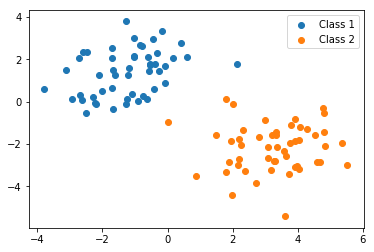

In [20]:
#plotting each class seperately, not important for training the models
X_1 = []
X_2 = []
for row in range(X_train.shape[0]):
    if Y_train[row] == 0:
        X_1.append(X_train[row,:])
    else:
        X_2.append(X_train[row,:])
X_1 = np.asarray(X_1)
X_2 = np.asarray(X_2)

plt.scatter(X_1[:,0], X_1[:,1], label="Class 1")
plt.scatter(X_2[:,0], X_2[:,1], label="Class 2")
plt.legend()
plt.show()

### Problem 1

Use logistic regression on the training data set X_train and Y_train, train a classifier. Compute and print the training precision and recall.

In [ ]:
#insert your code here

logreg_model_obj = LogisticRegression()

### Problem 2

Using a SVM on the training data set X_train and Y_train, train a classifier. Compute and print the training precision and recall. Use the model object function settings I've provided below.

In [ ]:
#insert your code here

svm_model_obj = SVC(gamma='auto', kernel='linear')

### Problem 3

Using the logistic regression model and SVM you've trained above, compute the precision and recall performance for each model on the testing data set X_test and Y_test.

In [23]:
#insert your code here

### Problem 4

The the noise in our data is Gaussian; compare the empirical mean and variance of the training and test data sets (remember, each row of the train and test sets are a 2-dimensional sample, so the empirical mean and variance are 2 dimensional). In your own words, why might the test performance be lower?

In [ ]:
#insert your code here

### Bonus 1

Create two scatter plots: one plot for the training data as above, and one for the test data. Use sklearn's model_object.decision_function() method to draw the decision boundaries of each model. A tutorial can be found [here](https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html) for plotting an SVM's decision function. The procedure for drawing the decision boundary is identical for the logistic regression model.

In [ ]:
#insert your code here

### Bonus 2

I've generated a data set that can only be seperated by a circle. This is the worst case scenario for a model that attempts to sepearte data with a straight line. But recall from our regression assignments: if we know the _type_ of function we want to fit, we can pass the data through a kernel (in this problem we use the [radial basis function](https://en.wikipedia.org/wiki/Radial_basis_function_kernel)---a very powerful basis). Using the svm model code you've written above and the data provided here, use the following model function settings to seperate the data and draw the decision boundary.

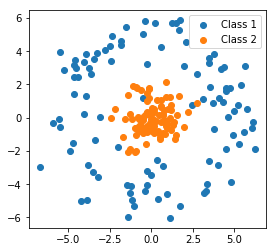

In [26]:
data_bonus = np.loadtxt("homework_5_bonus.txt")
X_b = data_bonus[:,0:2]
Y_b = data_bonus[:,2]

X_1 = []
X_2 = []
for row in range(X_b.shape[0]):
    if Y_b[row] == 0:
        X_1.append(X_b[row,:])
    else:
        X_2.append(X_b[row,:])
X_1 = np.asarray(X_1)
X_2 = np.asarray(X_2)

plt.gca().set_aspect('equal') 
plt.scatter(X_1[:,0], X_1[:,1], label="Class 1")
plt.scatter(X_2[:,0], X_2[:,1], label="Class 2")
plt.legend()
plt.show()

In [ ]:
#insert your code here

svm_model_obj = SVC(gamma='auto', kernel='rbf')